## <span style = "color: #9fcddfff;"> **Data Load & Preprocessing** </span>

Conv2D → produces activations

BatchNorm → normalizes those conv activations

MaxPooling → downsamples normalized features

Flatten → prepares for dense layers

In [ ]:

#Import data and preprocessing
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

#Model Development
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout, BatchNormalization, Flatten, MaxPooling2D, Conv2D
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#Model Finetuning Tools
from sklearn.decomposition import PCA
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Model Evaluations
import time
start_time = time.time()
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Random Seeds of 40 is used throughout the models for reproducibility
#np.random.seed(40)
#tf.random.set_seed(40)
random_state = 40

In [3]:
#Load data in
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

#Seperating the Features from the Labels
x = np.concatenate((train_images, test_images), axis=0)
y = np.concatenate((train_labels, test_labels), axis=0)

#Confirming Data Structure
print('The data structure for the total feature is:', x.shape)
print('The data structure for the total labels is:', y.shape)

#Confirming the data structures of the split data
print('\nThe training feature shape is:', train_images.shape)
print('The test feature shape is:', test_images.shape)
print('\nThe training labels shape is:', train_labels.shape)
print('The test labels shape is:', test_labels.shape)

The data structure for the total feature is: (60000, 32, 32, 3)
The data structure for the total labels is: (60000, 1)

The training feature shape is: (50000, 32, 32, 3)
The test feature shape is: (10000, 32, 32, 3)

The training labels shape is: (50000, 1)
The test labels shape is: (10000, 1)


In [4]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = 10

In [5]:
#Sklearn Model Data Preprocessing

#Feature Scaling
x_train = train_images.astype('float32') / 255.0
x_test = test_images.astype('float32') / 255.0

# Labels for Sklearn Models
y_train_sklearn = train_labels
y_test_sklearn = test_labels

# Data Reshaping for Features
reshape = 32 * 32 * 3
x_train_sklearn = x_train.reshape((x_train.shape[0], reshape))
x_test_sklearn = x_test.reshape((x_test.shape[0], reshape))

# Splitting the data into training and validation sets
x_train_sklearn, x_val_sklearn, y_train_sklearn, y_val_sklearn = train_test_split(
    x_train_sklearn, y_train_sklearn, test_size=0.2, random_state=random_state)

#Confirming the data structures after preprocessing for Sklearn Models
print('\nThe training feature shape for Sklearn Models is:', x_train_sklearn.shape)
print('The training labels shape for Sklearn Models is:', y_train_sklearn.shape)

print('\nThe test feature shape for Sklearn Models is:', x_test_sklearn.shape)
print('The test labels shape for Sklearn Models is:', y_test_sklearn.shape)

print('\nThe validation feature shape for Sklearn Models is:', x_val_sklearn.shape)
print('The validation labels shape for Sklearn Models is:', y_val_sklearn.shape)



The training feature shape for Sklearn Models is: (40000, 3072)
The training labels shape for Sklearn Models is: (40000, 1)

The test feature shape for Sklearn Models is: (10000, 3072)
The test labels shape for Sklearn Models is: (10000, 1)

The validation feature shape for Sklearn Models is: (10000, 3072)
The validation labels shape for Sklearn Models is: (10000, 1)


In [6]:
#Neural Network Model Data Preprocessing

# Feature Data Preprocessing
x_train_cnn = train_images.astype('float32') / 255.0
x_test_cnn = test_images.astype('float32') / 255.0

#Label Data Preprocessing
y_train_cnn = to_categorical(train_labels, num_classes)
y_test_cnn = to_categorical(test_labels, num_classes)

# Splitting the data into training and validation sets
x_train_cnn, x_val_cnn, y_train_cnn, y_val_cnn = train_test_split(x_train_cnn, y_train_cnn, test_size=0.2, random_state=random_state)

#Confirming the data structures after preprocessing for Neural Network Models
print('\nThe training feature shape for Neural Network Models is:', x_train_cnn.shape)
print('The training labels shape for Neural Network Models is:', y_train_cnn.shape)

print('\nThe test feature shape for Neural Network Models is:', x_test_cnn.shape)
print('The test labels shape for Neural Network Models is:', y_test_cnn.shape)

print('\nThe validation feature shape for Neural Network Models is:', x_val_cnn.shape)
print('The validation labels shape for Neural Network Models is:', y_val_cnn.shape)


The training feature shape for Neural Network Models is: (40000, 32, 32, 3)
The training labels shape for Neural Network Models is: (40000, 10)

The test feature shape for Neural Network Models is: (10000, 32, 32, 3)
The test labels shape for Neural Network Models is: (10000, 10)

The validation feature shape for Neural Network Models is: (10000, 32, 32, 3)
The validation labels shape for Neural Network Models is: (10000, 10)


### <span style = "color: #9fcddfff;"> **Data Exploration** </span>

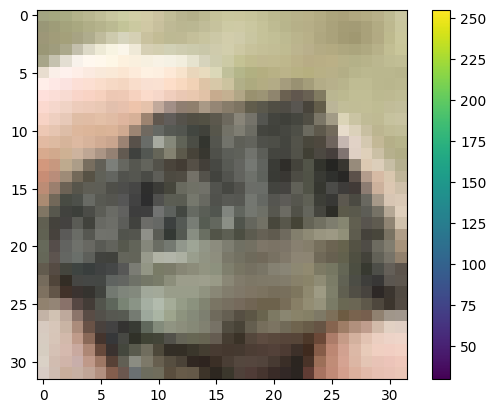

In [42]:
plt.figure()
# x_train was reshaped to (N, 3072). Use the unflattened array x_train_full (shape (N,32,32,3))
plt.imshow(train_images[25])
plt.colorbar()
plt.grid(False)
plt.show()

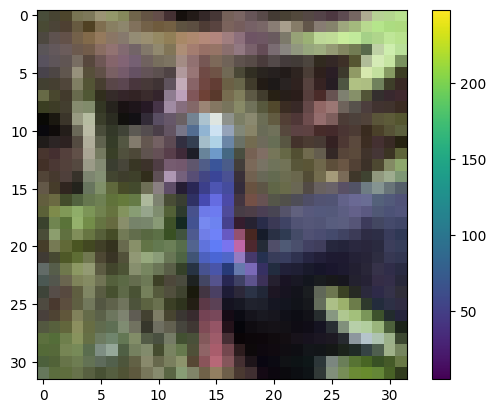

In [43]:
plt.figure()
# x_train was reshaped to (N, 3072). Use the unflattened array x_train_full (shape (N,32,32,3))
plt.imshow(train_images[24])
plt.colorbar()
plt.grid(False)
plt.show()

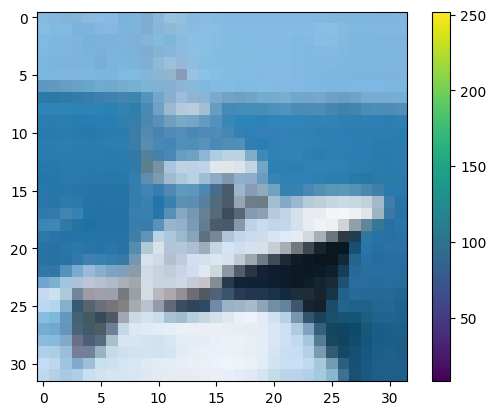

In [44]:
plt.figure()
plt.imshow(train_images[8])
plt.colorbar()
plt.grid(False)
plt.show()

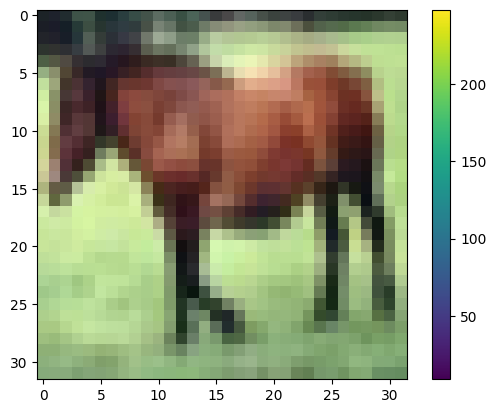

In [45]:
plt.figure()
plt.imshow(train_images[7])
plt.colorbar()
plt.grid(False)
plt.show()

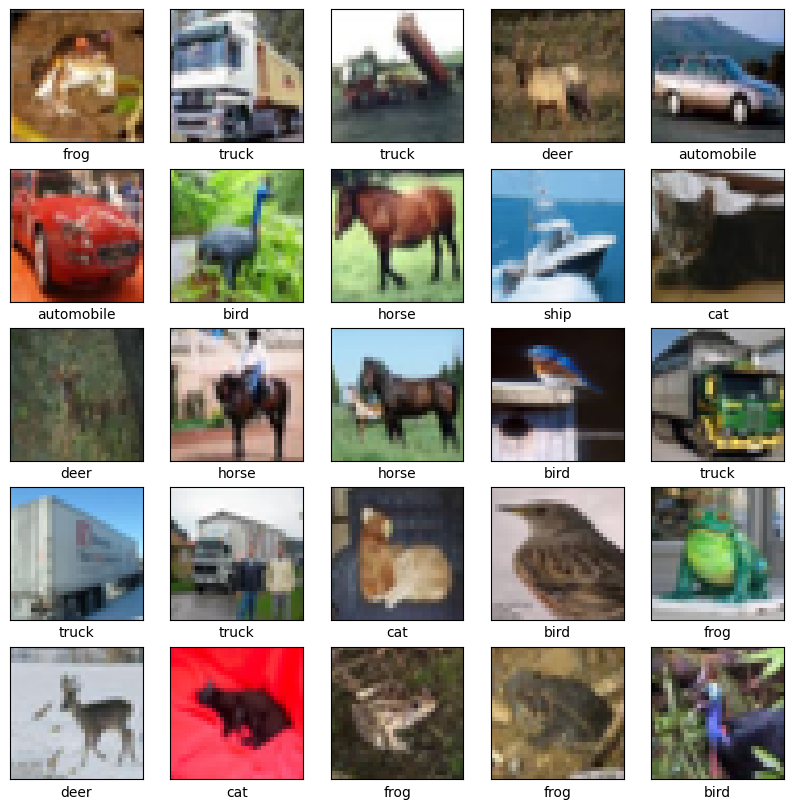

In [46]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    # train_labels has shape (N,1) so extract the scalar and cast to int for indexing
    plt.xlabel(classes[int(train_labels[i, 0])])
plt.show()

## <span style = "color: #9fcddfff;"> **Model Developments** </span>


### <span style = "color: #9fcddfff;"> **Sklearn/Traditional Models** </span>

In [ ]:
def evaluate_sklearn_model(model, x_train, y_train, x_val, y_val, model_name):
    """For sklearn models (returns class labels directly)"""
    # Training metrics
    start_time = time.time()
    y_train_pred = model.predict(x_train)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_val_pred = model.predict(x_val)
    inference_time = time.time() - start_time
    
    # Calculate accuracies
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {train_time:.4f}s")
    print(f"Inference Time: {inference_time:.4f}s")
    
    # Plot confusion matrix
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Plot accuracy comparison
    plt.subplot(1, 2, 2)
    metrics = ['Training', 'Validation']
    accuracies = [train_accuracy, val_accuracy]
    times = [train_time, inference_time]
    
    plt.bar(metrics, accuracies, color=['blue', 'orange'], alpha=0.7)
    plt.title(f'{model_name} - Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_time': train_time,
        'inference_time': inference_time,
        'confusion_matrix': cm
    }

#### <span style = "color: #9fcddfff;"> **Support Vector Machine** </span>

##### <span style = "color: #9fcddfff;"> **Experiment 1: Support Vector Machine _Baseline Model_** </span>

In [48]:
start_time = time.time()

svm_baseline = SVC(
    C = 1.0, #default resonable start
    kernel= 'rbf', #using the Rdial Basis Function because of its performance with non-linear and complex data 9instead of the linear kernel)
    gamma= 'scale',
    random_state= random_state,
    verbose= 1
)

#Fit Model
svm_baseline.fit(x_train_sklearn, y_train_sklearn)

#Assess training time
svm_baseline_time = time.time() - start_time

c:\Users\Sam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LibSVM]


=== SVM_basline ===
Training Accuracy: 0.7028
Validation Accuracy: 0.5257
Training Time: 2510.6600s
Inference Time: 724.5790s


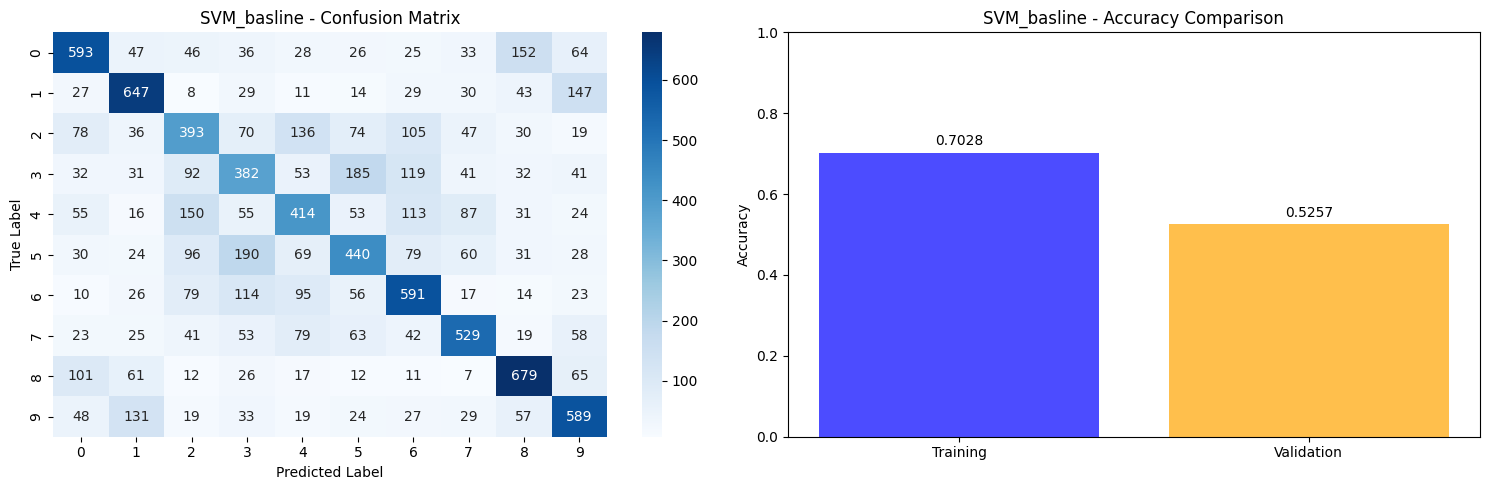

In [49]:
#Evaluate
svm_baseline_results = evaluate_sklearn_model(
    svm_baseline,
    x_train_sklearn, y_train_sklearn,
    x_val_sklearn, y_val_sklearn, 'SVM_basline'
)

_Due to the traunaing data and the model used- using PCA may improve possible noises, computational efficiency, and multicollinearity_

##### <span style = "color: #9fcddfff;"> **Experiment 2: Support Vector Machine _with Principal Component Analysis_** </span>

In [50]:
start_time = time.time()

pca_svm = PCA(n_components=0.95, random_state = random_state)
x_train_pca_svm = pca_svm.fit_transform(x_train_sklearn)
x_val_pca_svm = pca_svm.transform(x_val_sklearn)

print(f"Original dimension: {x_train_sklearn.shape[1]}")
print(f"PCA dimension (0.95 variance): {x_train_pca_svm.shape[1]}")
print(f"Variance retained: {np.sum(pca_svm.explained_variance_ratio_):.4f}")

# If the dimension is still too high, would use fixed components

if x_train_pca_svm.shape[1] > 200:
    print('Too many components, switching to fixed n_components=150')
    pca_svm = PCA(n_components=150, random_state = random_state)
    x_train_pca_svm = pca_svm.fit_transform(x_train_sklearn)
    x_val_pca_svm = pca_svm.transform(x_val_sklearn)
    print(f"New PCA dimension: {x_train_pca_svm.shape[1]}")

svm_pca = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    random_state=42,
    verbose=1
)

#Train model
svm_pca.fit(x_train_pca_svm, y_train_sklearn)

#Assess training time
svm_pca_time = time.time()- start_time

Original dimension: 3072
PCA dimension (0.95 variance): 216
Variance retained: 0.9501
Too many components, switching to fixed n_components=150
New PCA dimension: 150
[LibSVM]

c:\Users\Sam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== SVM_PCA ===
Training Accuracy: 0.6680
Validation Accuracy: 0.5253
Training Time: 142.2920s
Inference Time: 34.8379s


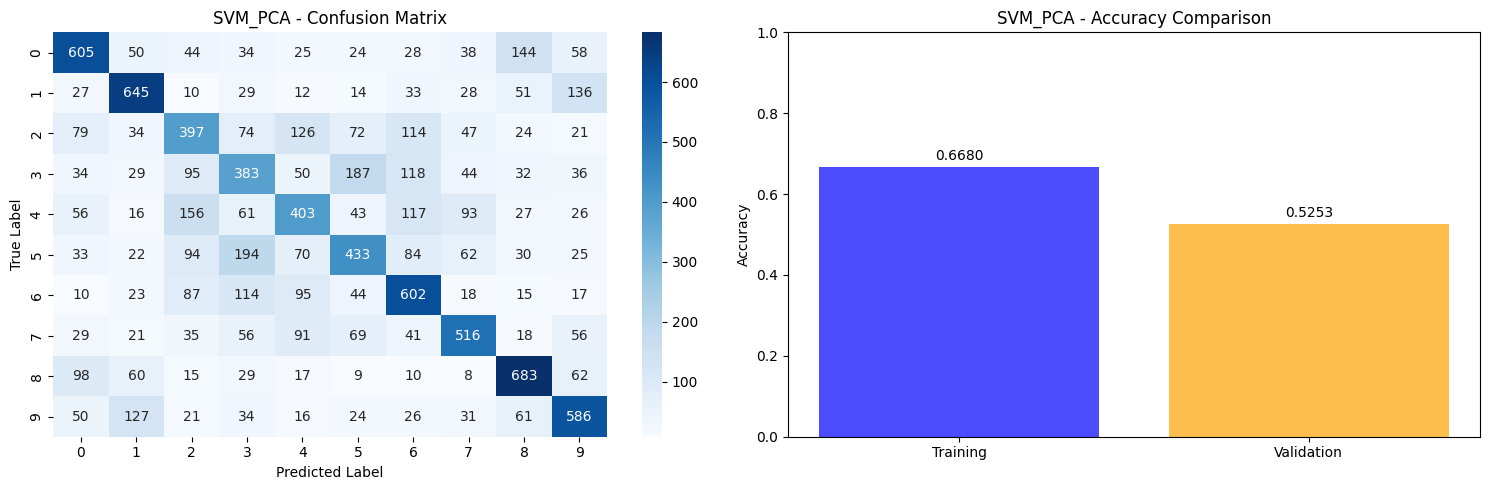

In [52]:
#Evaluate
svm_pca_results = evaluate_sklearn_model(
    svm_pca,
    x_train_pca_svm, y_train_sklearn,
    x_val_pca_svm, y_val_sklearn, 'SVM_PCA'
)

#### <span style = "color: #9fcddfff;"> **K-Nearest Neighbors** </span>

##### <span style = "color: #9fcddfff;"> **Experiment 1: K-Nearest Neighbors _Baseline Model_** </span>

In [53]:
start_time = time.time()

knn_baseline = KNeighborsClassifier(
    n_neighbors=5,  #Number ideal to balancce noise and locality
    weights='uniform', #All neighbors contribute equally
    n_jobs=-1 #Use all available cores for computation
)

#Train model
knn_baseline.fit(x_train_sklearn, y_train_sklearn)

#Assess training time
knn_baseline_time = time.time()- start_time

c:\Users\Sam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)



=== KNN_Baseline ===
Training Accuracy: 0.4973
Validation Accuracy: 0.3356
Training Time: 45.2705s
Inference Time: 10.4522s


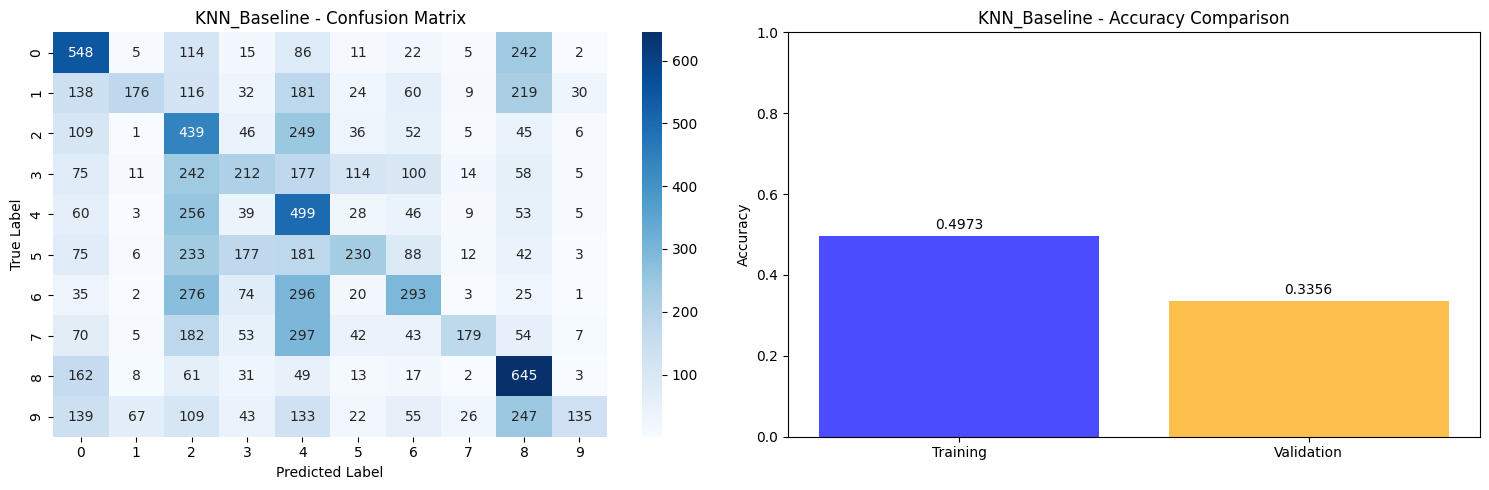

In [54]:
#Evaluate
knn_baseline_results = evaluate_sklearn_model(
    knn_baseline,
    x_train_sklearn, y_train_sklearn,
    x_val_sklearn, y_val_sklearn, 'KNN_Baseline'
)

##### <span style = "color: #9fcddfff;"> **Experiment 2: K-Nearest Neighbors _with Principal Component Analysis_** </span>

Optimizing the KNN model by changing from uniform to distance weights. _Uniform weighting treats all neighbors equally - whether they're very similar or just somewhat similar, they all get the same vote. Distance weighting is smarter - it gives more voting power to closer neighbors and less to distant ones_.

Also, PCA is essential for KNN because it solves the curse of dimensionality in image data. With thousands of pixels, all images appear equally distant, making neighbor-finding impossible. PCA extracts key patterns and compresses data to a space where distance becomes meaningful, allowing KNN to identify true similarities rather than random neighbors. 

Without PCA, KNN is essentially guessing randomly because the distance measurements are meaningless; with PCA, KNN can finally do its job properly by finding genuinely similar examples in this simplified, meaningful space

In [55]:
start_time = time.time()

pca_knn = PCA(n_components=0.95, random_state = random_state)
x_train_pca_knn = pca_knn.fit_transform(x_train_sklearn)
x_val_pca_knn = pca_knn.transform(x_val_sklearn)

print(f"Original dimension: {x_train_sklearn.shape[1]}")
print(f"PCA dimension (0.95 variance): {x_train_pca_knn.shape[1]}")
print(f"Variance retained: {np.sum(pca_knn.explained_variance_ratio_):.4f}")


#the lesser dimension- the better for KNN- 
# because by default KNN suffers from the 'curse of dimensionality'
# compared to SVM

if x_train_pca_knn.shape[1] > 50:
    print('Too many components, switching to fixed n_components=50')
    pca_knn = PCA(n_components=50, random_state = random_state)
    x_train_pca_knn = pca_knn.fit_transform(x_train_sklearn)
    x_val_pca_knn = pca_knn.transform(x_val_sklearn)
    print(f"New PCA dimension: {x_train_pca_knn.shape[1]}")
    print(f"Variance retained: {np.sum(pca_knn.explained_variance_ratio_):.4f}")


knn_pca = KNeighborsClassifier(
    n_neighbors=5,  #Number ideal to balancce noise and locality
    weights='distance', #Weight by distance to give closer neighbors more influence
    algorithm='auto', #Let sklearn choose the best algorithm based on data
    n_jobs=-1, #Use all available cores for computation
    metric='minkowski' #Generalization of Euclidean and Manhattan distances
)

#Train model
knn_pca.fit(x_train_pca_knn, y_train_sklearn)

#Assess training time
knn_pca_time = time.time()- start_time

Original dimension: 3072
PCA dimension (0.95 variance): 216
Variance retained: 0.9501
Too many components, switching to fixed n_components=50
New PCA dimension: 50
Variance retained: 0.8430


c:\Users\Sam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)



=== KNN_PCA ===
Training Accuracy: 1.0000
Validation Accuracy: 0.3947
Training Time: 1.2664s
Inference Time: 0.3226s


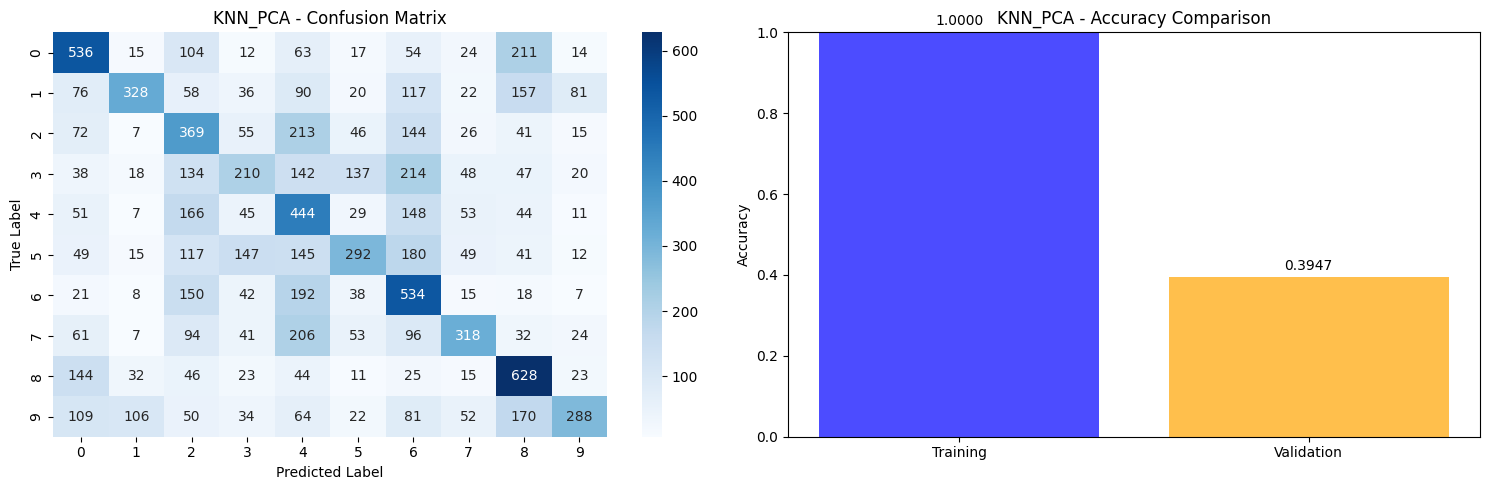

In [57]:
#Evaluate
knn_pca = evaluate_sklearn_model(
    knn_pca,
    x_train_pca_knn, y_train_sklearn,
    x_val_pca_knn, y_val_sklearn, 'KNN_PCA'
)

### <span style = "color: #9fcddfff;"> **Neural Network Models** </span>

In [10]:

def evaluate_neural_models(model, x_train, y_train, x_val, y_val, model_name, history=None):
    """For CNN models (returns probabilities)"""
    # Training metrics
    start_time = time.time()
    y_train_probs = model.predict(x_train)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_val_probs = model.predict(x_val)
    inference_time = time.time() - start_time
    
    # Convert predictions to class labels
    y_train_pred = np.argmax(y_train_probs, axis=1)
    y_val_pred = np.argmax(y_val_probs, axis=1)
    y_true_train = np.argmax(y_train, axis=1)
    y_true_val = np.argmax(y_val, axis=1)
    
    # Calculate accuracies
    train_accuracy = accuracy_score(y_true_train, y_train_pred)
    val_accuracy = accuracy_score(y_true_val, y_val_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_true_val, y_val_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Training Time: {train_time:.4f}s")
    print(f"Inference Time: {inference_time:.4f}s")
    
    # Create comprehensive plots
    plt.figure(figsize=(20, 5))
    
    # Plot 1: Training History (if available)
    if history is not None:
        plt.subplot(1, 4, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 4, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)
    else:
        # If no history, show accuracy comparison
        plt.subplot(1, 4, 1)
        metrics = ['Training', 'Validation']
        accuracies = [train_accuracy, val_accuracy]
        plt.bar(metrics, accuracies, color=['blue', 'orange'], alpha=0.7)
        plt.title('Accuracy Comparison')
        plt.ylabel('Accuracy')
        plt.ylim(0, 1)
        for i, v in enumerate(accuracies):
            plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
    
    # Plot 2: Confusion Matrix
    plt.subplot(1, 4, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Plot 3: Timing Comparison
    plt.subplot(1, 4, 4)
    times = [train_time, inference_time]
    labels = ['Training', 'Inference']
    plt.bar(labels, times, color=['green', 'red'], alpha=0.7)
    plt.title('Time Comparison')
    plt.ylabel('Time (seconds)')
    for i, v in enumerate(times):
        plt.text(i, v + 0.01, f'{v:.2f}s', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_time': train_time,
        'inference_time': inference_time,
        'confusion_matrix': cm,
        'history': history
    }

#### <span style = "color: #9fcddfff;"> **FeedForward Neural Network Model** </span>

##### <span style = "color: #9fcddfff;"> **Experiment 1: FeedForward Neural Network: _Baseline (Vanila) Model_** </span>

In [11]:
ffnn_baseline = Sequential([
    InputLayer(input_shape=(32, 32, 3)),
    Flatten(),                           
    Dense(512, activation='relu'),
    Dropout(0.3), #Due to high neurons and to prevent overfitting
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

#Model Compilation
ffnn_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ffnn_baseline.summary()

#Model Training
history_ffnn_baseline = ffnn_baseline.fit(
    x_train_cnn, y_train_cnn,
    validation_data =(x_val_cnn, y_val_cnn),
    epochs=20
)

c:\Users\Sam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2311 - loss: 2.0525 - val_accuracy: 0.2849 - val_loss: 1.9090
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2765 - loss: 1.9383 - val_accuracy: 0.3288 - val_loss: 1.8755
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2993 - loss: 1.8922 - val_accuracy: 0.3426 - val_loss: 1.8358
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3115 - loss: 1.8617 - val_accuracy: 0.3519 - val_loss: 1.7973
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3197 - loss: 1.8475 - val_accuracy: 0.3651 - val_loss: 1.7816
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3290 - loss: 1.8361 - val_accuracy: 0.3754 - val_loss: 1.7531
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3346 - loss: 1.8141 - val_accuracy: 0.3673 - val_loss: 1.7823
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3401 - loss: 1.8085 - 

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=== ffnn_baseline ===
Training Accuracy: 0.4068
Validation Accuracy: 0.3855
Training Time: 1.8128s
Inference Time: 0.5229s


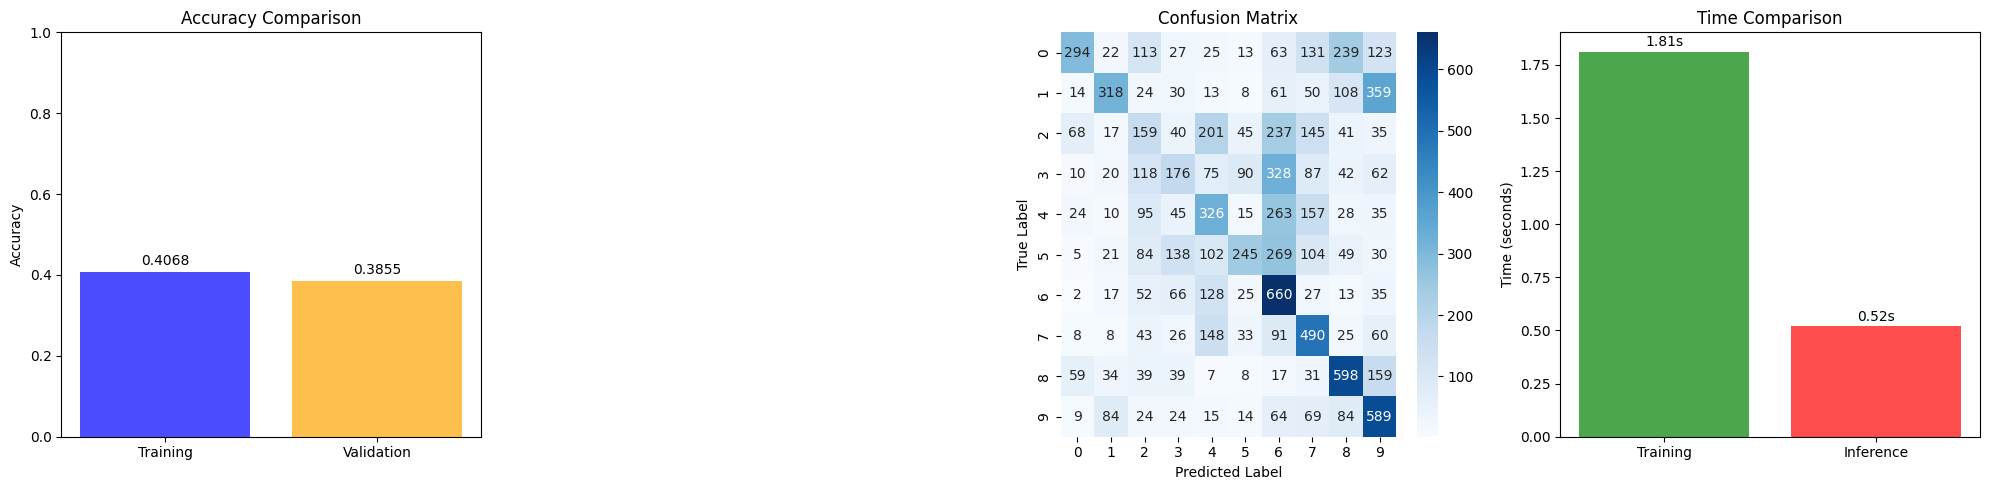

In [12]:
ffann_baseline_results = evaluate_neural_models(
    ffnn_baseline, 
    x_train_cnn, y_train_cnn,
    x_val_cnn,y_val_cnn,'ffnn_baseline'
)

##### <span style = "color: #9fcddfff;"> **Experiment 2: FeedForward Neural Network: _with KerasTuner_** </span>

In [30]:
def optimized_ffnn_model(hp):
    #To debug tghe issues with hyperparameters
    print("HP values:", hp.values)
    model= Sequential()

    model.add(InputLayer(input_shape=(32, 32, 3)))
    model.add(Flatten())

    #Global decision on dropout use or not
    use_dropout = hp.Boolean('use_dropout', default=False)

    #Input layer
    model.add(Dense(
        units=hp.Int('input_units', min_value=64, max_value=256, step=64),
        activation='relu',
        input_shape=(32, 32, 3)
    ))

    #Hidden Layers
    for i in range(hp.Int('num_layers', min_value=1, max_value=3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=512, step=64),
            activation=hp.Choice(f'activation_{i}', values=['relu', 'tanh'])
        ))

        if use_dropout:
            dropout_rate = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
            model.add(Dropout(rate=dropout_rate))
    
    #Output Layer
    model.add(Dense(num_classes, activation='softmax'))


    #Optimizer tuning
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')

    if optimizer_choice =='adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        momentum = hp.Float('momentum', min_value=0.0, max_value=0.9, step=0.1)
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)

    #Model Compilation
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [31]:
# import shutil
# shutil.rmtree('my_tuning', ignore_errors=True)
# shutil.rmtree('my_dir', ignore_errors=True)

In [32]:
# Initialize Model

tuner_ffnn = kt.Hyperband(
    optimized_ffnn_model, 
    objective= 'val_accuracy',
    max_epochs=20,
    #factor=3,
    directory='my_tuning',
    project_name='ffnn_experiment',
    overwrite=True
)

HP values: {}


In [33]:
# Tuner searches for best hyperparameters

tuner_ffnn.search(
    x_train_cnn, y_train_cnn,
    epochs=10,  
    validation_data=(x_val_cnn, y_val_cnn)
    #,batch_size=64                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
)

Trial 30 Complete [00h 00m 52s]
val_accuracy: 0.5181999802589417

Best val_accuracy So Far: 0.5181999802589417
Total elapsed time: 00h 09m 48s


In [34]:
best_ffnn = tuner_ffnn.get_best_models(num_models=1)[0]

HP values: {'use_dropout': False, 'input_units': 256, 'num_layers': 2, 'units_0': 512, 'activation_0': 'tanh', 'optimizer': 'sgd', 'lr': 0.0024186545482647744, 'dropout_0': 0.4, 'units_1': 64, 'activation_1': 'tanh', 'dropout_1': 0.30000000000000004, 'units_2': 448, 'activation_2': 'tanh', 'dropout_2': 0.1, 'momentum': 0.7000000000000001, 'tuner/epochs': 20, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


In [35]:
# Train best model
history_ffnn_tuned = best_ffnn.fit(
    x_train_cnn, y_train_cnn,
    validation_data=(x_val_cnn, y_val_cnn),
    epochs=20,
    #batch_size=128,
    verbose=1
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5872 - loss: 1.1586 - val_accuracy: 0.5142 - val_loss: 1.3986
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5936 - loss: 1.1440 - val_accuracy: 0.5217 - val_loss: 1.3679
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5987 - loss: 1.1297 - val_accuracy: 0.5261 - val_loss: 1.3498
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6033 - loss: 1.1161 - val_accuracy: 0.5117 - val_loss: 1.4145
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6095 - loss: 1.1017 - val_accuracy: 0.5106 - val_loss: 1.4035
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6133 - loss: 1.0853 - val_accuracy: 0.5129 - val_loss: 1.4290
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6216 - loss: 1.0714 - val_accuracy: 0.5013 - val_loss: 1.4448
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6250 - loss: 1.0551 - 

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

=== optimized_ffnn ===
Training Accuracy: 0.6878
Validation Accuracy: 0.5198
Training Time: 1.8237s
Inference Time: 0.5365s


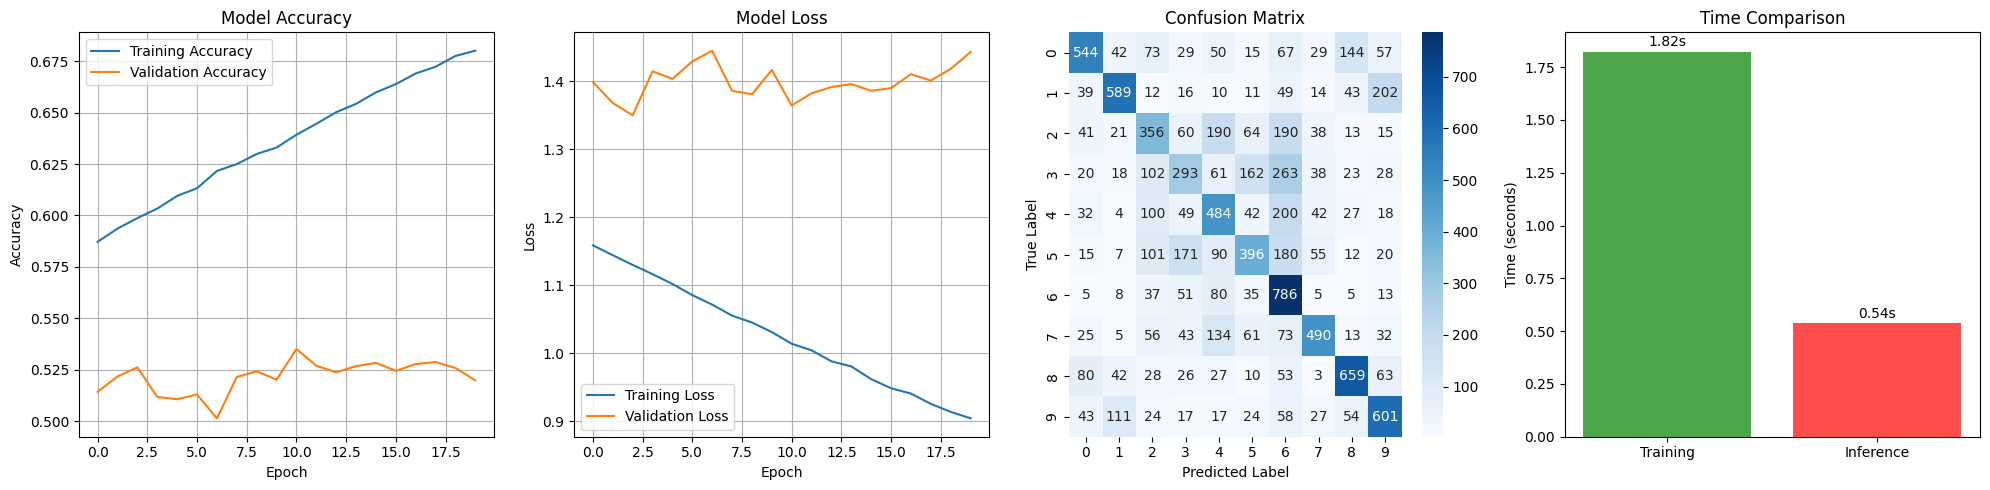

In [36]:
optimized_ffnn_results = evaluate_neural_models(
    best_ffnn, 
    x_train_cnn, y_train_cnn,
    x_val_cnn,y_val_cnn,'optimized_ffnn', history=history_ffnn_tuned
)

----

#### <span style = "color: #9fcddfff;"> **Convolutional Neural Network** </span>

##### <span style = "color: #9fcddfff;"> **Experiment 1: Convolutional Neural Network: _Baseline (Vanila) Model_** </span>

In [23]:
cnn_baseline = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

#Model Compilation
cnn_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_baseline.summary()

#Model Training
history_cnn_baseline = cnn_baseline.fit(
    x_train_cnn, y_train_cnn,
    validation_data=(x_val_cnn, y_val_cnn),
    epochs=20
)

c:\Users\kojus\anaconda3\envs\ML_DM\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.3868 - loss: 1.6693 - val_accuracy: 0.5027 - val_loss: 1.3828
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5208 - loss: 1.3228 - val_accuracy: 0.6020 - val_loss: 1.1334
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.5760 - loss: 1.1858 - val_accuracy: 0.6365 - val_loss: 1.0420
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.6072 - loss: 1.0935 - val_accuracy: 0.6593 - val_loss: 0.9757
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 71s 40ms/step - accuracy: 0.6346 - loss: 1.0237 - val_accuracy: 0.6671 - val_loss: 0.9686
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.6513 - loss: 0.9730 - val_accuracy: 0.6793 - val_loss: 0.9312
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.6649 - loss: 0.9293 - val_accuracy: 0.6891 - val_loss: 0.9101
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.6800 -

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== <keras.src.callbacks.history.History object at 0x000001FB59235890> ===
Training Accuracy: 0.9221
Validation Accuracy: 0.7035
Training Time: 2.4509s
Inference Time: 0.6811s


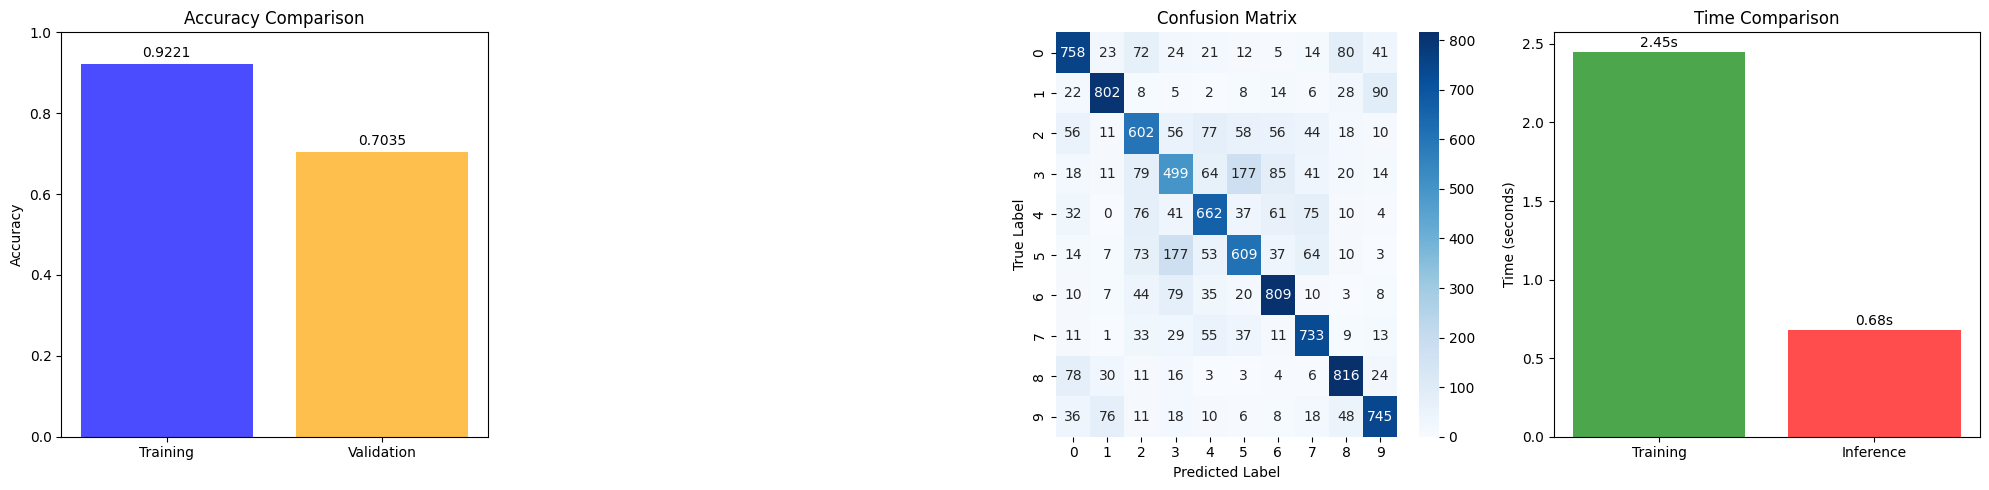

In [38]:
cnn_baseline_results = evaluate_neural_models(
    cnn_baseline,
    x_train_cnn, y_train_cnn,
    x_val_cnn, y_val_cnn,
    history_cnn_baseline
)

##### <span style = "color: #9fcddfff;"> **Experiment 2: Convolutional Neural Network: _with KerasTuner [Optional Data Augmentataion, Batch Normalization and Dropout]_** </span>

In [7]:
def optimized_cnn(hp):
    model = Sequential()

    #Global Decisions: Let Tuner decide 
    use_dropout = hp.Boolean('use_dropout', default=False)
    use_batch_normalization = hp.Boolean('use_batch_normalization', default=False)
    use_data_augmentation = hp.Boolean('use_data_augmentation', default=False)

    model.add(
        Conv2D(
            filters=hp.Int('filters_0',  min_value=64, max_value=512, step=64),
            kernel_size=hp.Int('kernel_0', min_value = 3, max_value=5, step=1),
            activation='relu',
            padding='same',
            input_shape=(32,32,3)
        ))

    #Optional BatchNorm
    if use_batch_normalization: 
        model.add(BatchNormalization())

    #MaxPooling
    model.add(MaxPooling2D((2,2)))

    #Optional Dropout
    if use_dropout:
        dropout_rate = hp.Float('conv_dropout_0', min_value = 0.1, max_value =0.4, step=0.1)
        model.add(Dropout(rate=dropout_rate))

    #Addiitional Con Layer
    for i in range(hp.Int('num_conv_layers', min_value=1, max_value=3)):
        model.add(Conv2D(
            filters=hp.Int(f'filters_{i+1}', min_value=32, max_value=256, step=32),
            kernel_size = hp.Int(f'Kernel_{i+1}', min_value=3, max_value=5),
            activation='relu',
            padding='same'
        ))

        #Optional BatchNorm
        if use_batch_normalization:
            model.add(BatchNormalization())

        #Optional MaxPooling
        if hp.Boolean(f'pooling_{i+1}', default=True):
            model.add(MaxPooling2D((2,2)))
        
        #Optional Dropout
        if use_dropout:
            dropout_rate = hp.Float(f'conv_dropout_{i+1}', min_value = 0.1, max_value=0.4, step=0.1)
            model.add(Dropout(rate=dropout_rate))

    model.add(Flatten())

    #Global decision
    if use_dropout:
        dense_dropout = hp.Float('dense_dropout', min_value=0.3,max_value=0.6, step=0.1)

    
    # Dense Layers (1-2 layers)
    for i in range(hp.Int('num_dense_layers', 1, 2)):
        model.add(Dense(
            units=hp.Int(f'dense_units_{i}', 64, 512, step=64),
            activation=hp.Choice(f'dense_activation_{i}', ['relu', 'tanh'])
        ))
        
        if optimized_cnn:
            model.add(BatchNormalization())
            
        if use_dropout:
            model.add(Dropout(rate=dense_dropout))
    
    # Output Layer
    model.add(Dense(10, activation='softmax'))
    
    # Optimizer tuning (same as your FFNN approach)
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
    
    if optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        momentum = hp.Float('momentum', min_value=0.0, max_value=0.9, step=0.1)
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    
    # Model compilation
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [ ]:

# # Data augmentation function (only used if tuner selects it)
# def get_data_augmentation():
#     return ImageDataGenerator(
#         rotation_range=15,
#         width_shift_range=0.1,
#         height_shift_range=0.1,
#         horizontal_flip=True,
#         zoom_range=0.1,
#         fill_mode='nearest'
#     )
# # ========== TUNER SETUP AND TRAINING ==========
# print("Setting up CNN with Keras Tuner and Optional Data Augmentation...")

# # Use HyperBand for efficient tuning
# tuner_cnn = kt.Hyperband(
#     optimized_cnn,
#     objective='val_accuracy',
#     max_epochs=5,
#     factor=3,
#     directory='cnn_tuning',
#     project_name='cifar10_cnn_refined',
#     overwrite=True
# )

# # Search callbacks for early stopping
# stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# # Perform the search
# print("Starting hyperparameter search...")
# tuner_cnn.search(
#     x_train_cnn, y_train_cnn,
#     validation_data=(x_val_cnn, y_val_cnn),
#     epochs=5,
#     #batch_size=64,
#     callbacks=[stop_early],
#     verbose=1
# )

# # Get best hyperparameters
# best_hps = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

# print("\nBest Hyperparameters Found:")
# print(f"Use Data Augmentation: {best_hps.get('use_data_augmentation')}")
# print(f"Use Dropout: {best_hps.get('use_dropout')}")
# print(f"Use BatchNorm: {best_hps.get('use_batchnorm')}")
# print(f"Number of Conv Layers: {best_hps.get('num_conv_layers') + 1}")
# print(f"Number of Dense Layers: {best_hps.get('num_dense_layers')}")
# print(f"Optimizer: {best_hps.get('optimizer')}")
# print(f"Learning Rate: {best_hps.get('lr')}")

Trial 9 Complete [00h 56m 22s]
val_accuracy: 0.5835000276565552

Best val_accuracy So Far: 0.7317000031471252
Total elapsed time: 1d 00h 05m 14s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
True              |True              |use_dropout
True              |False             |use_batch_normalization
False             |False             |use_data_augmentation
256               |192               |filters_0
4                 |5                 |kernel_0
3                 |2                 |num_conv_layers
128               |160               |filters_1
5                 |3                 |Kernel_1
True              |False             |pooling_1
1                 |1                 |num_dense_layers
448               |448               |dense_units_0
relu              |relu              |dense_activation_0
rmsprop           |rmsprop           |optimizer
0.0017386         |0.00018821        |lr
0.2               |0.1               |conv_dropout_0
0.3 

KeyboardInterrupt: 

In [ ]:
# # Get best model
# best_optimized_cnn = tuner_cnn.get_best_models(num_models=1)[0]

# # Check if we should use data augmentation
# use_augmentation = best_hps.get('use_data_augmentation')

# if use_augmentation:
#     print("Training best model WITH data augmentation...")
#     datagen = get_data_augmentation()
#     datagen.fit(x_train_cnn)
    
#     history_cnn_tuned = best_optimized_cnn.fit(
#         datagen.flow(x_train_cnn, y_train_cnn, batch_size=64),
#         steps_per_epoch=len(x_train_cnn) // 64,
#         validation_data=(x_val_cnn, y_val_cnn),
#         epochs=50,
#         callbacks=[stop_early],
#         verbose=1
#     )

# else:
#     print("Training best model WITHOUT data augmentation")
#     history_cnn_tuned = best_optimized_cnn.fit(
#         x_train_cnn, y_train_cnn,
#         validation_data=(x_val_cnn, y_val_cnn),
#         epochs=50,
#         batch_size=64,
#         callbacks=[stop_early],
#         verbose=1
#     )

In [ ]:
# cnn_optimized_results = evaluate_neural_models(
#     best_optimized_cnn,
#     x_train_cnn, y_train_cnn,
#     x_val_cnn, y_val_cnn,
#     history_cnn_baseline
# )

### <span style = "color: #9fcddfff;"> **Ensemble Model _(CNN + KNN)_** </span>

__Why Ensemble Model:__

- Scenario: Two uncertain models vs one very certain model
    - model1: [0.51, 0.49] → "class 0" (barely sure)
    - model2: [0.52, 0.48] → "class 0" (barely sure) 
    - model3: [0.05, 0.95] → "class 1" (very sure)

- _Hard voting_: "class 0" wins (2 vs 1) ← WRONG!
- _Soft voting_: [0.36, 0.64] → "class 1" ← CORRECT!


__Will be using the weighted average (soft) instead of the hard voting (highest class)__

In [24]:
# ========== SOFT ENSEMBLE WITH ALL MODELS ==========
def soft_ensemble_all_models(x_data_nn, x_data_sklearn):
    """Combine predictions from ALL models using soft voting
    """
    all_probs = []
    
    # 1. CNN Baseline predictions
    cnn_baseline_probs = cnn_baseline.predict(x_data_nn, verbose=0)
    all_probs.append(cnn_baseline_probs)
    print("CNN Baseline probabilities added")
    
    # 2. CNN Optimized predictions (with Keras Tuner)
    # cnn_optimized_probs = best_optimized_cnn.predict(x_data_nn, verbose=0)
    # all_probs.append(cnn_optimized_probs)
    # print("CNN Optimized probabilities added")

      # 3. Feed-Forward Neural Network predictions- baseline model
    ffnn_baseline_probs = ffnn_baseline.predict(x_data_nn, verbose=0)
    all_probs.append(ffnn_baseline_probs)
    print("Feed-Forward baseline probabilities added")

      # 4. Optimized Feed-Forward Neural Network predictions (with Keras Tuner)
    ffnn_optimized_probs = best_ffnn.predict(x_data_nn, verbose=0)
    all_probs.append(ffnn_optimized_probs)
    print("FFNN Optimized probabilities added")
    
    # 5. SVM Baseline predictions
    svm_baseline_probs = svm_baseline.predict_proba(x_data_sklearn)
    all_probs.append(svm_baseline_probs)
    print("SVM Baseline probabilities added")
    
    # 6. KNN Baseline predictions  
    knn_baseline_probs = knn_baseline.predict_proba(x_data_sklearn)
    all_probs.append(knn_baseline_probs)
    print("KNN Baseline probabilities added")
    
    # 7. SVM with PCA predictions
    x_sklearn_pca_svm = pca_svm.transform(x_data_sklearn)
    svm_pca_probs = svm_pca.predict_proba(x_sklearn_pca_svm)
    all_probs.append(svm_pca_probs)
    print("SVM with PCA probabilities added")
    
    # 8. KNN with PCA predictions
    x_sklearn_pca_knn = pca_knn.transform(x_data_sklearn)
    knn_pca_probs = knn_pca.predict_proba(x_sklearn_pca_knn)
    all_probs.append(knn_pca_probs)
    print("KNN with PCA probabilities added")
    
    # Average all probabilities (soft voting)
    ensemble_probs = np.mean(all_probs, axis=0)
    ensemble_preds = np.argmax(ensemble_probs, axis=1)
    
    print(f"Combined {len(all_probs)} models using soft voting")
    return ensemble_preds

class AllModelsEnsemble:
    def __init__(self):
        self.name = "AllModels_Soft_Ensemble"
    
    def predict(self, x_cnn_data, x_sklearn_data):
        return soft_ensemble_all_models(x_cnn_data, x_sklearn_data)

In [25]:
def evaluate_ensemble_single(ensemble_model, x_cnn_data, x_sklearn_data, y_true, dataset_name="dataset"):
    """Evaluate ensemble model on a single dataset
    Args:
        ensemble_model: Your trained ensemble model
        x_cnn_data: CNN format data to evaluate on (x_val_cnn, x_test_cnn, etc.)
        x_sklearn_data: Sklearn format data to evaluate on (x_val_sklearn, x_test_sklearn, etc.)
        y_true: True labels for the data (np.argmax(y_val_cnn, axis=1), etc.)
        dataset_name: Name for printing (e.g., "validation", "test")
        Because ensmeble models do not train- they only combine the models to return a better performance score; only validation
        and or test may deally be used in the arguments and not training.
    """
    results = {}
    
    print(f"Evaluating ensemble on {dataset_name} data")
    start_time = time.time()
    predictions = ensemble_model.predict(x_cnn_data, x_sklearn_data)
    inference_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, predictions)
    conf_matrix = confusion_matrix(y_true, predictions)
    class_report = classification_report(y_true, predictions, output_dict=True)
    
    results['model_name'] = ensemble_model.name
    results['dataset_name'] = dataset_name
    results['accuracy'] = accuracy
    results['inference_time'] = inference_time
    results['confusion_matrix'] = conf_matrix
    results['classification_report'] = class_report
    results['predictions'] = predictions
    
    print(f"\n=== {ensemble_model.name} - {dataset_name.upper()} Results ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Inference Time: {inference_time:.4f} seconds")
    print(f"Samples evaluated: {len(y_true)}")
    
    return results

In [26]:
# Evaluate on VALIDATION set
all_models_ensemble = AllModelsEnsemble()

ensemble_val_results = evaluate_ensemble_single(
    all_models_ensemble,
    x_val_cnn,          # Validation CNN data
    x_val_sklearn,      # Validation sklearn data  
    np.argmax(y_val_cnn, axis=1),  # Convert from one-hot to integers
    "validation"
)


Evaluating ensemble on validation data


CNN Baseline probabilities added


NameError: name 'ffnn_baseline' is not defined

## <span style = "color: #9fcddfff;"> **Model Evaluation** </span>

In [ ]:
def evaluate_all_models_simple(x_test_cnn, x_test_sklearn, y_test_true):
    "To evaluate all models on test data"

    #All models to evaluate:
    #
    models_to_evaluate = [
    #Sklearn Model:
    ('SVM_Baseline', svm_baseline, 'sklearn', None),
    ('KNN_Baseline', knn_baseline, 'sklearn', None),
    ('SVM_PCA', svm_baseline, 'sklearn', pca_svm),
    ('KNN_PCA', knn_pca, 'sklearn', pca_knn),

    #Neural Network
    ('CNN_Baseline', cnn_baseline, 'cnn', None),
    ('FFNN_Baseline', ffnn_baseline, 'cnn', None),
    ('Optimized_FFNN', best_ffnn, 'cnn', None),
    ('Optimized_CNN', best_optimized_cnn, 'cnn', None),

    #ensemmble_model
    ('Ensemble_All', all_models_ensemble, 'ensemble', None)
    ]

    results = {}

    print('Evaluating all models on test data')

    for name, model, model_type, pca, in models_to_evaluate:
        start_time = time.time()

        if model_type == 'cnn':
            preds= np.argmax(model.predict(x_test_cnn, xverbose=0), axis=1)
        elif model_type== 'sklearn':
            if pca:
                data = pca.transform(x_test_sklearn)
            else:
                data = x_test_sklearn
        else: #ensemble
            preds = model.predict(x_test_cnn, x_test_sklearn)

        time_taken = time.time() - start_time
        accuracy = accuracy_score(y_test_true, preds)

        results[name] = {
            'accuracy': accuracy,
            'inference_time': time_taken,
            'predictions': preds
                 }
        
        print(f"{name} - Accuracy: {accuracy:.4f}, Inference Time: {time_taken:.4f}s")

        best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
        print(f"\n🎯 Best Model: {best_model[0]} (Accuracy: {best_model[1]['accuracy']:.4f})")

    return results

